In [33]:
from google.colab import files
uploaded = files.upload()

Saving netflix_cleaned (1).xlsx to netflix_cleaned (1) (1).xlsx


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
df = pd.read_excel("netflix_cleaned (1).xlsx")
print(df)

       show_id     type                                         title  \
0        10192    Movie                           Shrek Forever After   
1        27205    Movie                                     Inception   
2        12444    Movie  Harry Potter and the Deathly Hallows: Part 1   
3        38757    Movie                                       Tangled   
4        10191    Movie                      How to Train Your Dragon   
...        ...      ...                                           ...   
31986   285142  TV Show                                         直面疾风吧   
31987   280684  TV Show                                A Better Place   
31988   259018  TV Show                                    Jane Smith   
31989   283306  TV Show             The Fear Clinic: Face Your Phobia   
31990   283387  TV Show            Everybody's Live with John Mulaney   

                primary_country                                   country  \
0      United States of America               

In [36]:
df.head()

,show_id,type,title,primary_country,country,date_added,release_year,primary_genre,genres,language,popularity,vote_count,vote_average,budget,revenue,seasons
0,10192,Movie,Shrek Forever After,United States of America,United States of America,2010-05-16,2010,Comedy,"Comedy, Adventure, Fantasy, Animation, Family",en,203.893,7449,6.380,165000000.0,752600867.0,NaN
1,27205,Movie,Inception,United Kingdom,"United Kingdom, United States of America",2010-07-15,2010,Action,"Action, Science Fiction, Adventure",en,156.242,37119,8.369,160000000.0,839030630.0,NaN
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,United Kingdom,"United Kingdom, United States of America",2010-11-17,2010,Adventure,"Adventure, Fantasy",en,121.191,19327,7.744,250000000.0,954305868.0,NaN
3,38757,Movie,Tangled,United States of America,United States of America,2010-11-24,2010,Animation,"Animation, Family, Adventure",en,111.762,11638,7.600,260000000.0,592461732.0,NaN
4,10191,Movie,How to Train Your Dragon,United States of America,United States of America,2010-03-18,2010,Fantasy,"Fantasy, Adventure, Animation, Family",en,110.044,13259,7.800,165000000.0,494879471.0,NaN


In [37]:
df.shape

(31991, 16)

In [67]:
language_map = {
    'en': 'English',
    'zh': 'Chinese',
    'ja': 'Japanese',
    'ko': 'Korean',
    'es': 'Spanish',
    'fr': 'French',
    'de': 'German',
    'hi': 'Hindi',
    'ta': 'Tamil',
    'pt': 'Portuguese',
    'tl': 'Telugu'
}
df['language'] = df['language'].astype(str).str.strip().str.lower()
df['language'] = df['language'].replace(language_map)
print(df['language'].value_counts())

language
english     13969
chinese      2834
japanese     2784
korean       2240
spanish      1646
            ...  
az              1
as              1
or              1
mt              1
za              1
Name: count, Length: 83, dtype: int64


In [38]:
df.columns

Index(['show_id', 'type', 'title', 'primary_country', 'country', 'date_added',
       'release_year', 'primary_genre', 'genres', 'language', 'popularity',
       'vote_count', 'vote_average', 'budget', 'revenue', 'seasons'],
      dtype='object')

In [39]:
df.dtypes

,0
show_id,int64
type,object
title,object
primary_country,object
country,object
date_added,datetime64[ns]
release_year,int64
primary_genre,object
genres,object
language,object


In [40]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
primary_country,0
country,0
date_added,0
release_year,0
primary_genre,0
genres,0
language,0


In [41]:
df = df.dropna(how='all')

In [42]:
df.shape

(31991, 16)

In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
df.describe()

,show_id,date_added,release_year,popularity,vote_count,vote_average,budget,revenue,seasons
count,3.199100e+04,31991,31991.000000,31991.000000,31991.000000,31991.000000,4.847000e+03,5.645000e+03,15991.0
mean,3.266265e+05,2017-12-24 06:32:25.222093568,2017.497890,42.625323,412.951330,5.688119,2.893928e+07,6.933733e+07,1.0
min,1.890000e+02,2010-01-01 00:00:00,2010.000000,2.323000,0.000000,0.000000,1.000000e+00,2.000000e+00,1.0
25%,8.212400e+04,2013-12-31 00:00:00,2013.000000,10.472000,2.000000,5.300000,3.898000e+06,1.100000e+06,1.0
50%,2.095720e+05,2017-12-29 00:00:00,2017.000000,22.067000,43.000000,6.500000,1.050000e+07,8.555008e+06,1.0
75%,4.468610e+05,2021-12-30 00:00:00,2021.000000,41.549000,192.000000,7.300000,3.000000e+07,4.915834e+07,1.0
max,1.440471e+06,2025-12-31 00:00:00,2025.000000,6421.923000,37119.000000,10.000000,4.600000e+08,2.799439e+09,1.0
std,3.389658e+05,NaN,4.608776,112.095299,1562.757896,2.634548,4.708018e+07,1.795958e+08,0.0


In [52]:
df['type'].value_counts()

,count
type,
Movie,16000
TV Show,15991


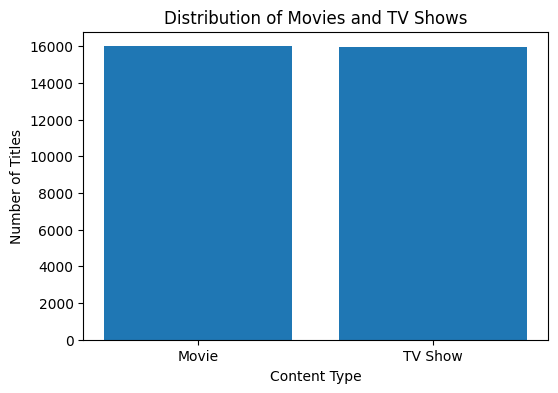

In [51]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(6,4))

plt.bar(type_counts.index, type_counts.values)

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

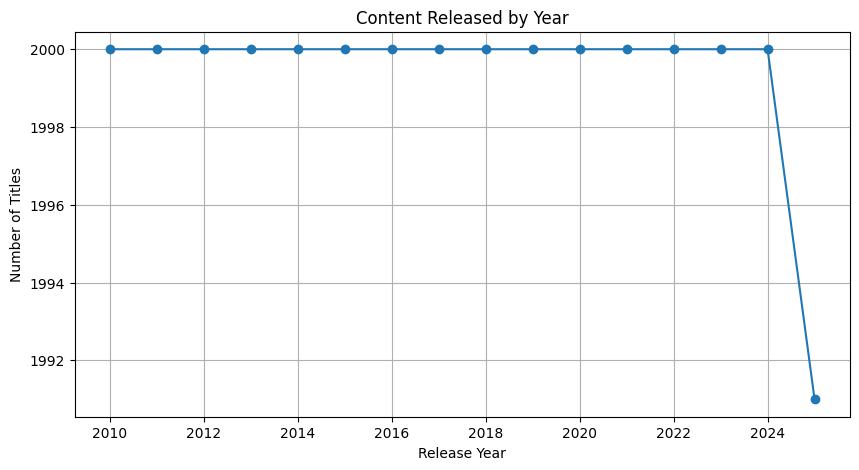

In [55]:
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(year_counts.index, year_counts.values, marker='o')

plt.title("Content Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)
plt.show()

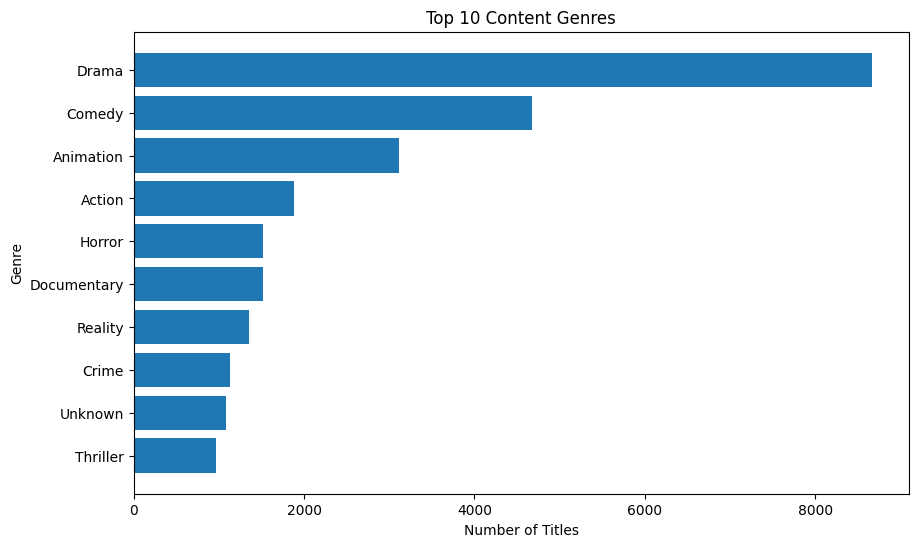

In [58]:
genre_counts = df['primary_genre'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.barh(genre_counts.index[::-1], genre_counts.values[::-1])

plt.title("Top 10 Content Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

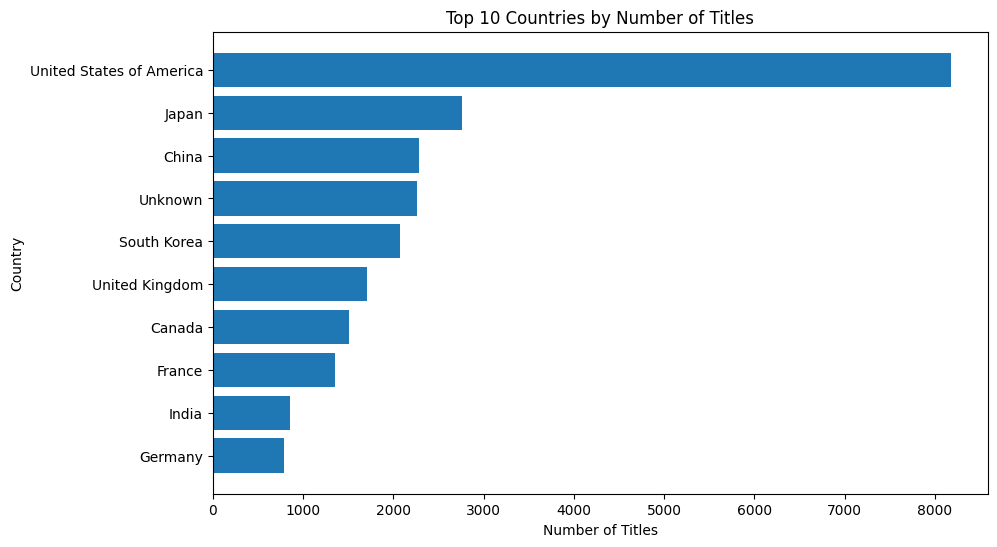

In [60]:
country_counts = df['primary_country'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.barh(country_counts.index[::-1], country_counts.values[::-1])

plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

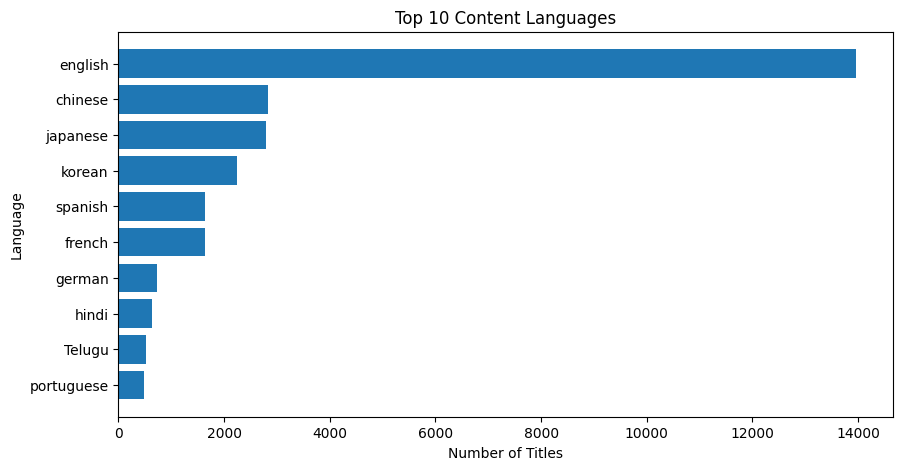

In [71]:
language_counts = df['language'].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.barh(language_counts.index[::-1], language_counts.values[::-1])

plt.title("Top 10 Content Languages")
plt.xlabel("Number of Titles")
plt.ylabel("Language")

plt.show()

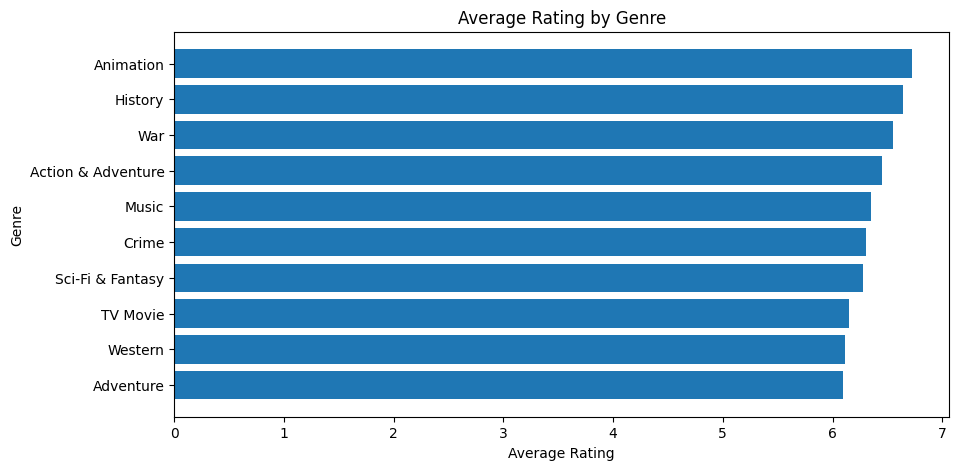

In [70]:
genre_rating = (df.groupby('primary_genre')['vote_average'].mean().sort_values(ascending=False).head(10))
plt.figure(figsize=(10,5))
plt.barh(genre_rating.index[::-1], genre_rating.values[::-1])
plt.title("Average Rating by Genre")
plt.xlabel("Average Rating")
plt.ylabel("Genre")

plt.show()

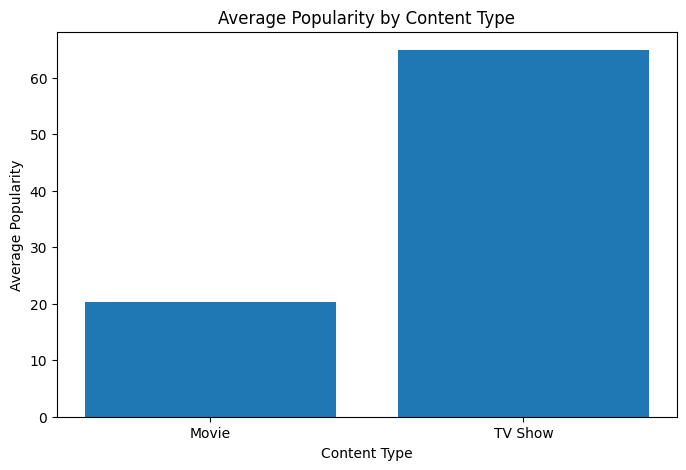

In [73]:
popularity_type = df.groupby('type')['popularity'].mean()

plt.figure(figsize=(8,5))
plt.bar(popularity_type.index, popularity_type.values)

plt.title("Average Popularity by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Average Popularity")

plt.show()

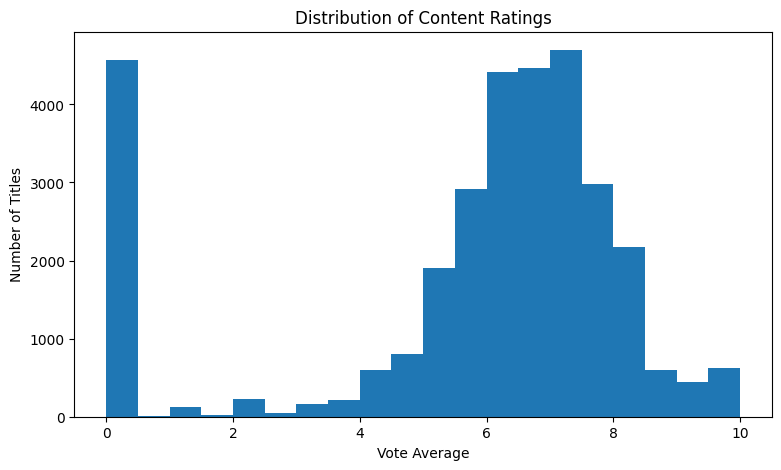

In [75]:
plt.figure(figsize=(9,5))

plt.hist(df['vote_average'].dropna(), bins=20)

plt.title("Distribution of Content Ratings")
plt.xlabel("Vote Average")
plt.ylabel("Number of Titles")

plt.show()